In [1]:
%load_ext autoreload
%autoreload 2

import os

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import sys
sys.path.append('../src')
from utils import *

In [2]:
size = 32

In [14]:
index = 4

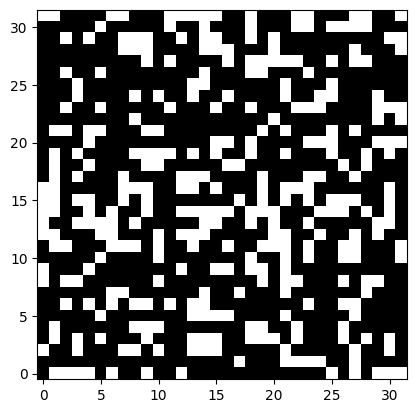

In [15]:
topologies = pd.read_csv(f'../working/topologies_{size}x{size}.csv', header=None)
topology = topologies.iloc[index].values.reshape(size,size)
plt.imshow(topology, cmap='gray', origin='lower')

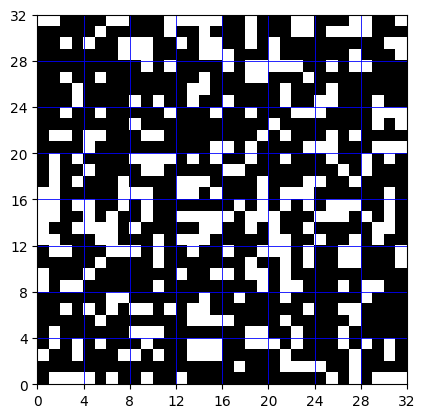

In [16]:
def plot_topology(topology, size):
    step = size // 8
    ticks = np.arange(0, size + 1, step)
    plt.xticks(ticks)
    plt.yticks(ticks)
    plt.grid(color='blue', linestyle='-', linewidth=0.6)
    plt.imshow(topology, cmap='gray', origin='lower', extent=(0,size,0,size))
    plt.show()
    
plot_topology(topology, size)

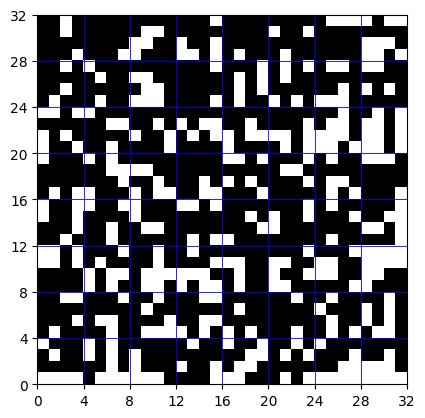

In [61]:
def fix_inlet_outlet(topology, size):
    topology_fixed = topology.copy()
    s = size // 8
    topology_fixed[s:2*s, 0] = 0
    topology_fixed[-2*s:-s, 0] = 0
    topology_fixed[s:2*s, -1] = 0
    topology_fixed[-2*s:-s, -1] = 0
    return topology_fixed

fixed_topology = fix_inlet_outlet(topology, size)
plot_topology(fixed_topology, size)

In [65]:
new_topologies = []
for i in range(len(topologies)):
    topology = topologies.iloc[i].values.reshape(size,size)
    fixed_topology = fix_inlet_outlet(topology, size)
    new_topologies.append(fixed_topology.flatten())
    
new_topologies_df = pd.DataFrame(new_topologies)
new_topologies_df.to_csv(f'../working/topologies_{size}x{size}_fixed.csv', index=False, header=None)

In [66]:
topologies

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,True,False,True,False,True,False,False,False,True,True,...,True,True,True,True,True,True,True,True,True,False
1,False,False,True,False,False,False,True,True,True,False,...,True,True,False,False,False,False,True,True,False,False
2,True,True,True,True,False,True,True,True,True,True,...,False,False,False,True,True,True,True,False,True,True
3,False,True,True,True,False,True,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
4,False,True,True,True,True,False,True,False,False,True,...,True,True,False,False,False,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,True,False,False,False,False,False,False,False,False,False,...,True,True,True,True,False,True,True,False,True,True
730,False,True,True,True,True,False,True,True,True,False,...,True,False,False,True,True,True,True,False,True,True
731,True,False,False,True,True,True,False,True,False,True,...,False,True,True,True,True,True,True,True,False,True
732,True,False,False,True,True,True,True,True,False,False,...,True,True,False,True,True,True,False,False,False,True


In [67]:
new_topologies_df

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,True,False,True,False,True,False,False,False,True,True,...,True,True,True,True,True,True,True,True,True,False
1,False,False,True,False,False,False,True,True,True,False,...,True,True,False,False,False,False,True,True,False,False
2,True,True,True,True,False,True,True,True,True,True,...,False,False,False,True,True,True,True,False,True,True
3,False,True,True,True,False,True,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
4,False,True,True,True,True,False,True,False,False,True,...,True,True,False,False,False,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,True,False,False,False,False,False,False,False,False,False,...,True,True,True,True,False,True,True,False,True,True
730,False,True,True,True,True,False,True,True,True,False,...,True,False,False,True,True,True,True,False,True,True
731,True,False,False,True,True,True,False,True,False,True,...,False,True,True,True,True,True,True,True,False,True
732,True,False,False,True,True,True,True,True,False,False,...,True,True,False,True,True,True,False,False,False,True
